In [1]:
import os

if not os.path.exists("/content/dl-soundstream-codec"):
    !git clone https://github.com/MathUmkaaa/dl-soundstream-codec.git

%cd /content/dl-soundstream-codec

!pip install -q -r requirements.txt
!pip install -q gdown onnxruntime

import torch, torchaudio
print(torch.__version__, torchaudio.__version__, torch.cuda.is_available())

Cloning into 'dl-soundstream-codec'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 141 (delta 36), reused 115 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 432.74 KiB | 13.11 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/dl-soundstream-codec
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.0/787.0 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 

In [2]:
!python scripts/download_checkpoint.py
!mkdir -p data && cd data && wget -q --show-progress https://www.openslr.org/resources/12/test-clean.tar.gz && tar -xzf test-clean.tar.gz && rm test-clean.tar.gz
!ls data/LibriSpeech/test-clean | head


Downloading...
From (original): https://drive.google.com/uc?id=1sTm7sgaQnJE0vV7g5NOiKzUF5WGa7nzg
From (redirected): https://drive.google.com/uc?id=1sTm7sgaQnJE0vV7g5NOiKzUF5WGa7nzg&confirm=t&uuid=5e8b53a1-e087-4edd-843b-21ac28578cc7
To: /content/dl-soundstream-codec/checkpoints/model_best.pth
100% 124M/124M [00:03<00:00, 40.5MB/s]
test-clean.tar.gz   100%[===================>] 330.60M  19.1MB/s    in 18s     
1089
1188
121
1221
1284
1320
1580
1995
2094
2300


In [3]:
import torch
import torch.nn.functional as F
import torchaudio
import urllib.request
import matplotlib.pyplot as plt
from IPython.display import Audio

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

from src.model import SoundStream

model = SoundStream()
model = model.to(device)

checkpoint = torch.load("checkpoints/model_best.pth", map_location=device, weights_only=False)
checkpoint = checkpoint["state_dict"]

model.load_state_dict(checkpoint)
model.eval()

cuda


SoundStream(
  (encoder): Encoder(
    (layers): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): EncoderBlock(
        (layers): Sequential(
          (0): ResidualUnit(
            (layers): Sequential(
              (0): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,))
              (1): ELU(alpha=1.0)
              (2): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
              (3): ELU(alpha=1.0)
            )
          )
          (1): ResidualUnit(
            (layers): Sequential(
              (0): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(9,), dilation=(3,))
              (1): ELU(alpha=1.0)
              (2): Conv1d(32, 32, kernel_size=(1,), stride=(1,))
              (3): ELU(alpha=1.0)
            )
          )
          (2): ResidualUnit(
            (layers): Sequential(
              (0): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(27,), dilation=(9,))
              (1): ELU(alpha=1.0)
     

LJSpeech, English:

In [4]:
AUDIO_TEST = "https://keithito.com/LJ-Speech-Dataset/LJ025-0076.wav"

audio_path = "/tmp/input.wav"
urllib.request.urlretrieve(AUDIO_TEST, audio_path)


('/tmp/input.wav', <http.client.HTTPMessage at 0x7d134d590410>)

In [5]:
wav, sr = torchaudio.load(audio_path)

if wav.shape[0] > 1:
    wav = wav.mean(dim=0, keepdim=True)

wav = torchaudio.functional.resample(wav, sr, 16000)

pad = (-wav.shape[-1]) % 200
wav = F.pad(wav, (0, pad), mode="replicate")

x = wav.unsqueeze(0).to(device)

with torch.no_grad():
    recon1, recon2,recon3 = model(x)

orig_lj = wav.squeeze(0).cpu()
recon_lj = recon1.squeeze(0).squeeze(0).cpu()

print(orig_lj.shape, recon_lj.shape)


torch.Size([134400]) torch.Size([134400])


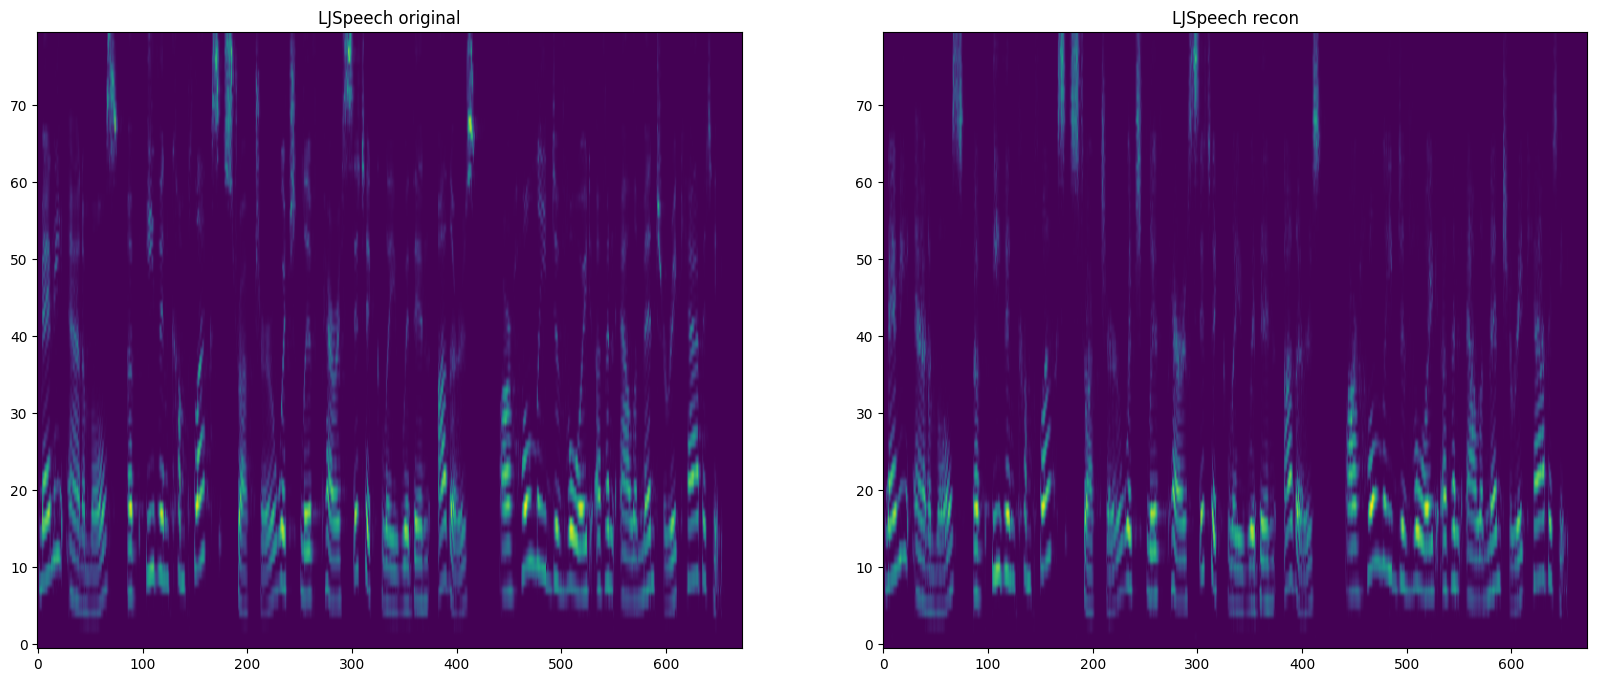

In [6]:
mel = torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_mels=80)

m_orig = mel(orig_lj).log1p()
m_recon = mel(recon_lj).log1p()

fig, ax = plt.subplots(1, 2, figsize=(20, 8))
ax[0].imshow(m_orig.numpy(), origin="lower", aspect="auto")
ax[0].set_title("LJSpeech original")
ax[1].imshow(m_recon.numpy(), origin="lower", aspect="auto")
ax[1].set_title("LJSpeech recon")
plt.show()


Judging by the pictures, it's possible that some of the peaks and "sharp" changes weren't very well reproduced, but overall, it turned out very similar

In [7]:
print("Original")
Audio(orig_lj.numpy(), rate=16000)

Original


In [8]:
print("Recon")
Audio(recon_lj.numpy(), rate=16000)

Recon


In [9]:
from torchmetrics.audio import ShortTimeObjectiveIntelligibility
from torchmetrics.audio.nisqa import NonIntrusiveSpeechQualityAssessment

stoi = ShortTimeObjectiveIntelligibility(16000)
nisqa = NonIntrusiveSpeechQualityAssessment(16000)

stoi_lj = stoi(recon_lj, orig_lj).item()

print("LJSpeech STOI:", stoi_lj)

LJSpeech STOI: 0.9360323548316956


In [10]:
nisqa_lj = nisqa(recon_lj)[0].item()

print("LJSpeech NISQA:", nisqa_lj)

downloading https://github.com/gabrielmittag/NISQA/raw/refs/heads/master/weights/nisqa.tar to /root/.torchmetrics/NISQA/nisqa.tar
INFO:torchmetrics:downloading https://github.com/gabrielmittag/NISQA/raw/refs/heads/master/weights/nisqa.tar to /root/.torchmetrics/NISQA/nisqa.tar


LJSpeech NISQA: 3.2966904640197754


Russian

In [11]:
wav, sr = torchaudio.load("my_test_audio.wav")

if wav.shape[0] > 1:
    wav = wav.mean(dim=0, keepdim=True)

wav = torchaudio.functional.resample(wav, sr, 16000)

pad = (-wav.shape[-1]) % 200
wav = F.pad(wav, (0, pad), mode="replicate")

x = wav.unsqueeze(0).to(device)

with torch.no_grad():
    recon1, recon2,recon3 = model(x)

orig_ru = wav.squeeze(0).cpu()
recon_ru = recon1.squeeze(0).squeeze(0).cpu()

print(orig_ru.shape, recon_ru.shape)

torch.Size([74200]) torch.Size([74200])


In [12]:
stoi_ru = stoi(recon_ru, orig_ru).item()

print("Russian STOI:", stoi_ru)

Russian STOI: 0.9260390400886536


In [13]:
nisqa_ru = nisqa(recon_ru)[0].item()

print("Russian NISQA:", nisqa_ru)

Russian NISQA: 2.5760092735290527


In [14]:
print("Original")
Audio(orig_ru.numpy(), rate=16000)

Original


In [15]:
print("Recon")
Audio(recon_ru.numpy(), rate=16000)

Recon


LibriSpeech - test-clean

In [17]:
!python eval.py \
  --ckpt checkpoints/model_best.pth \
  --data_dir data/LibriSpeech/test-clean \
  --device cuda


100% 2620/2620 [13:47<00:00,  3.17it/s]
STOI 0.9146580318913204
NISQA 2.5254390793902273
